# Лабораторная работа по теме: Освоение базового ML-пайплайна на табличных данных
Выполнил: Панарин Максим Валерьевич, М8О - 102БВ - 25

## Описание задачи

В работе решаются две задачи на одном датасете о образе жизни студентов:

| Задача | Модель | Целевая переменная | Тип |
|---|---|---|---|
| Предсказание успеваемости | Линейная регрессия | `CGPA` | Числовой (float) |
| Выявление депрессии | Логистическая регрессия | `Depression` | Бинарный (bool) |

**Датасет:** Student Depression and Lifestyle (100 000 записей, 10 признаков)


## Загрузка данных

In [1]:
import sys
import os

sys.path.insert(0, os.path.join(os.getcwd(), 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

from src.preparing_data_for_model import prepare_data
from src.learn_models import (
    learn_linear_reg_model,
    check_linear_model_error_RMSE,
    check_linear_model_error_r2,
    check_linear_model_error_MAE,
    learn_logistic_reg_model,
    check_logistic_reg_model_error,
    cross_validate_logistic_model,
)
from sklearn.metrics import f1_score

sns.set_theme(style="whitegrid")
print("Все модули успешно импортированы")


Все модули успешно импортированы


In [2]:
path = '/Users/maxim/.cache/kagglehub/datasets/aldinwhyudii/student-depression-and-lifestyle-100k-data/versions/1'
df = pd.read_csv(f'{path}/student_lifestyle_100k.csv')
df = df.drop(columns=["Student_ID"])

print(f"Размер датасета: {df.shape}")
df.head()


Размер датасета: (100000, 10)


,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


### 1.1 Общая информация о датасете


In [3]:
print(f"Строк: {df.shape[0]}, признаков: {df.shape[1]}")
print(f"\nПропущенные значения:\n{df.isna().sum()}")
print(f"\nДубликаты: {df.duplicated().sum()}")
df.info()


Строк: 100000, признаков: 10

Пропущенные значения:
Age                   0
Gender                0
Department            0
CGPA                  0
Sleep_Duration        0
Study_Hours           0
Social_Media_Hours    0
Physical_Activity     0
Stress_Level          0
Depression            0
dtype: int64

Дубликаты: 0
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Age                 100000 non-null  int64  
 1   Gender              100000 non-null  str    
 2   Department          100000 non-null  str    
 3   CGPA                100000 non-null  float64
 4   Sleep_Duration      100000 non-null  float64
 5   Study_Hours         100000 non-null  float64
 6   Social_Media_Hours  100000 non-null  float64
 7   Physical_Activity   100000 non-null  int64  
 8   Stress_Level        100000 non-null  int64  
 9   Depression          100000 

In [4]:
df.describe()


,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,21.009010,2.898316,6.996425,4.509517,3.503288,74.353180,4.131660
std,2.000382,0.532240,1.498682,1.976076,1.486852,43.366963,1.424151
min,18.000000,1.560000,3.000000,0.000000,0.000000,0.000000,2.000000
25%,19.000000,2.450000,6.000000,3.200000,2.500000,37.000000,3.000000
50%,21.000000,2.900000,7.000000,4.500000,3.500000,74.000000,4.000000
75%,23.000000,3.350000,8.000000,5.800000,4.500000,112.000000,5.000000
max,24.000000,4.000000,12.000000,12.800000,10.000000,149.000000,10.000000


**Вывод:** датасет содержит 100 000 записей без пропущенных значений и дубликатов — дополнительная очистка не требуется. Все числовые признаки имеют разумные диапазоны значений. Целевая переменная `Depression` бинарная.


### 1.2 Распределение числовых признаков


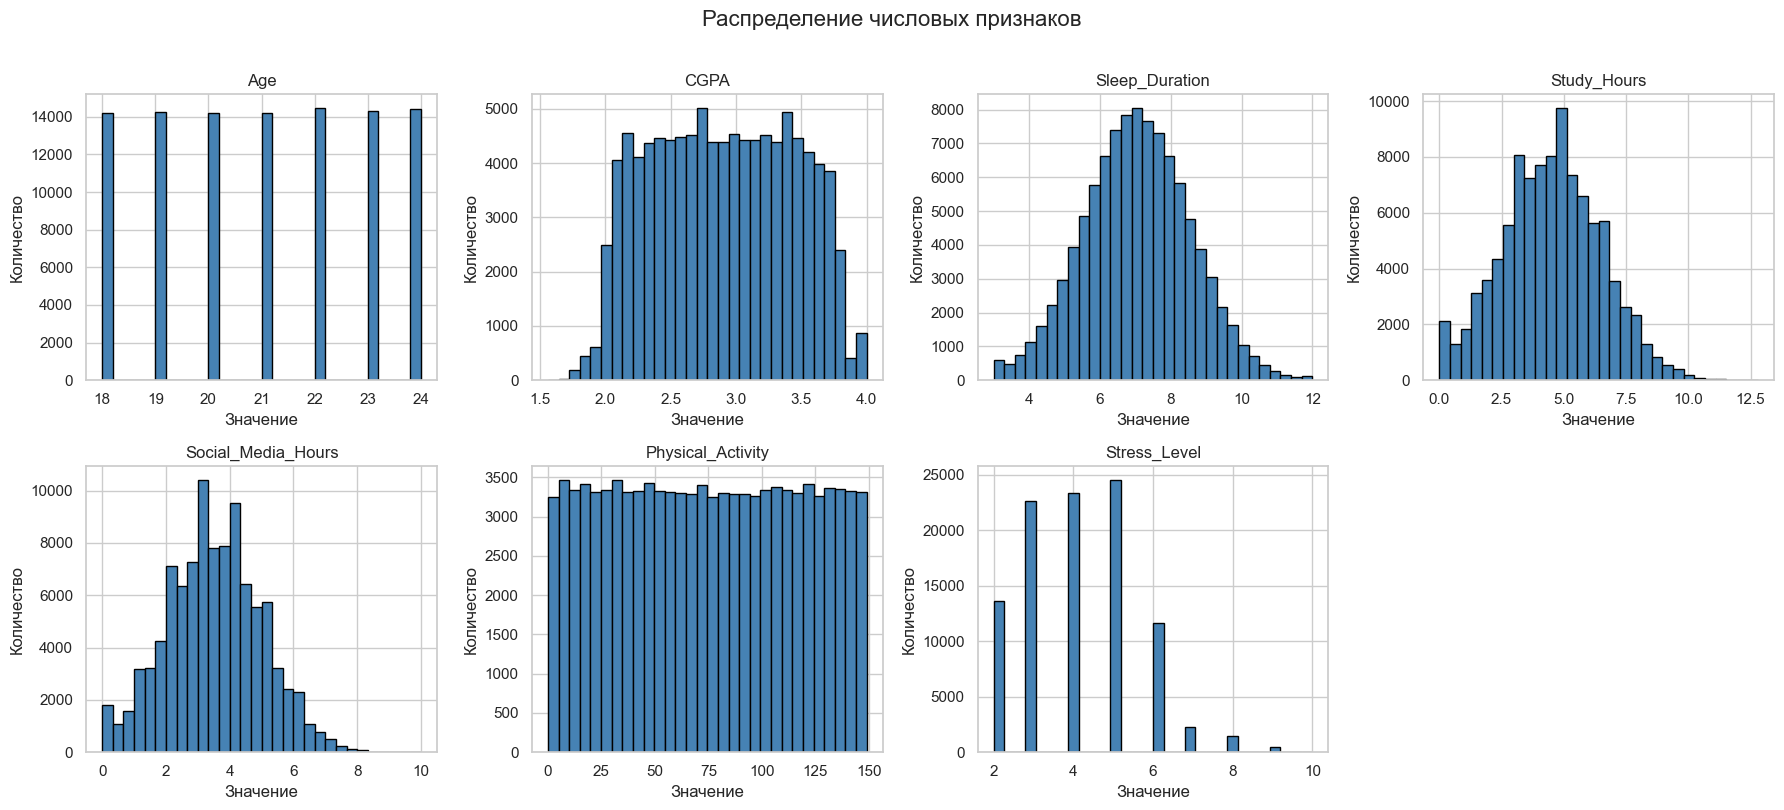

In [5]:
numeric_features = ['Age', 'CGPA', 'Sleep_Duration', 'Study_Hours',
                    'Social_Media_Hours', 'Physical_Activity', 'Stress_Level']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    axes[i].hist(df[feature], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(f'{feature}', fontsize=12)
    axes[i].set_xlabel('Значение')
    axes[i].set_ylabel('Количество')

axes[-1].axis('off')
plt.suptitle('Распределение числовых признаков', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


**Вывод:** большинство числовых признаков распределены равномерно или близко к нормальному — это благоприятно для линейных моделей. `CGPA` и `Sleep_Duration` имеют симметричное распределение. `Physical_Activity` и `Stress_Level` дискретные, что объясняет ступенчатый вид гистограмм.


### 1.3 Распределение категориальных признаков и целевой переменной


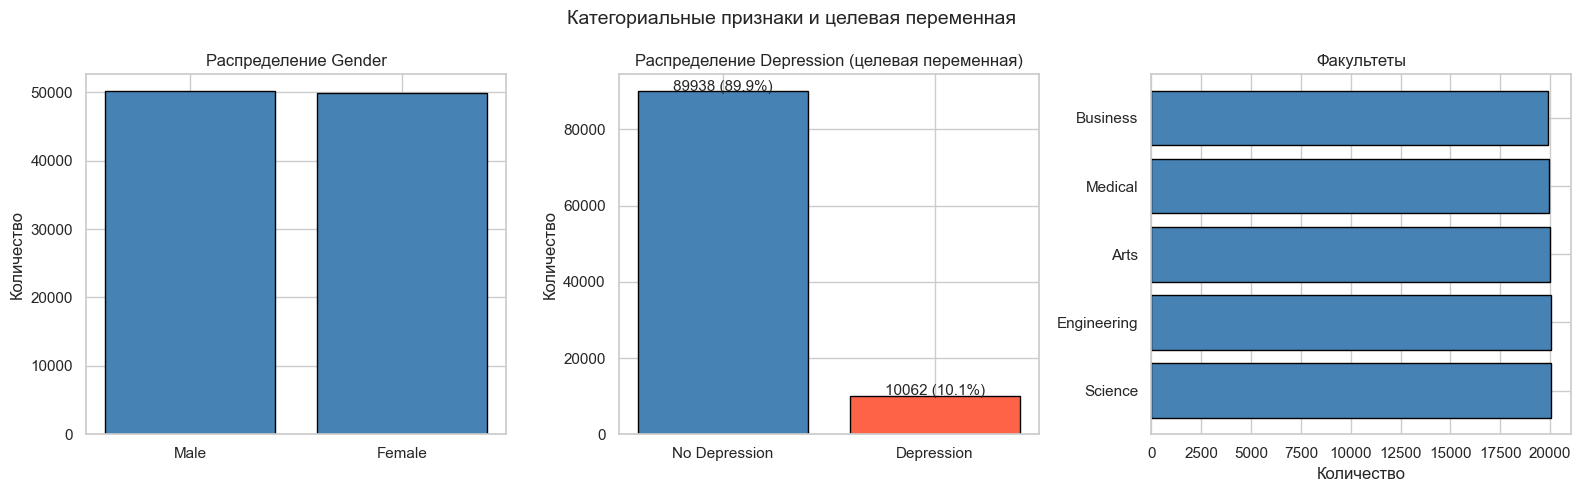


Дисбаланс классов Depression:
Depression
False    89938
True     10062
Name: count, dtype: int64


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gender
gender_counts = df['Gender'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values, color='steelblue', edgecolor='black')
axes[0].set_title('Распределение Gender')
axes[0].set_ylabel('Количество')

# Depression
dep_counts = df['Depression'].value_counts()
axes[1].bar(['No Depression', 'Depression'], dep_counts.values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[1].set_title('Распределение Depression (целевая переменная)')
axes[1].set_ylabel('Количество')
for i, v in enumerate(dep_counts.values):
    axes[1].text(i, v + 200, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontsize=11)

# Department
dept_counts = df['Department'].value_counts().head(10)
axes[2].barh(dept_counts.index, dept_counts.values, color='steelblue', edgecolor='black')
axes[2].set_title('Факультеты')
axes[2].set_xlabel('Количество')

plt.suptitle('Категориальные признаки и целевая переменная', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nДисбаланс классов Depression:")
print(dep_counts)


**Вывод:** выявлен значительный дисбаланс целевой переменной — депрессия встречается примерно у 10% студентов (~9:1). Это делает стандартную точность (accuracy) неинформативной метрикой и требует специальных техник балансировки (SMOTE) при обучении классификатора.


## 2. Предобработка данных

### 2.1 Кодирование категориальных признаков

Признаки `Gender` и `Department` являются номинальными категориальными — применяем **One-Hot Encoding** (`pd.get_dummies`), чтобы модель не воспринимала их как упорядоченные числа.


In [7]:
encoded_df = pd.get_dummies(df, columns=["Gender", "Department"])
print(f"Признаков до кодирования: {df.shape[1]}")
print(f"Признаков после кодирования: {encoded_df.shape[1]}")
encoded_df.head(3)


Признаков до кодирования: 10
Признаков после кодирования: 15


,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression,Gender_Female,Gender_Male,Department_Arts,Department_Business,Department_Engineering,Department_Medical,Department_Science
0,22,3.50,7.3,3.3,3.4,114,5,False,True,False,False,False,False,False,True
1,20,2.72,5.5,7.2,6.0,142,2,False,False,True,False,False,True,False,False
2,20,3.01,5.4,2.3,1.8,137,3,False,False,True,False,False,False,True,False


### 2.2 Feature Engineering

Создаём новые признаки на основе доменных знаний о психологии студентов:

| Признак | Описание |
|---|---|
| `Is_Recovery` | Оптимальный сон 7–9 часов |
| `Is_Procrastination` | Соцсети > 5 часов в день |
| `High_Stress` | Уровень стресса > 6 |
| `Low_Physical_Activity` | Физ. активность < 30 мин |
| `Sleep_Deficit` | Сон < 6 часов |
| `Sleep_Stress_Ratio` | Сон / Стресс |
| `Daily_Hours_Sleep_Ratio` | (Учёба + Соцсети) / Сон |
| `Is_High_CGPA` | CGPA > 3.4 (только для логистической регрессии) |
| `Stress_Physical_Ratio` | Стресс / Физ. активность (только для логистической регрессии) |


In [10]:
# Feature engineering выполняется внутри prepare_data автоматически.
# Список новых признаков, которые будут добавлены:

base_cols = set(encoded_df.columns)

from src.analythis.feature_engineering import (
    add_feature_high_stress, add_feature_is_person_recovery,
    add_feature_is_procrastination, add_feature_low_physical_activity,
    add_feature_sleep_deficit, add_feature_sleep_stress_ratio,
    add_feature_social_media_plus_study_sleep_ratio,
    add_feature_is_high_cgpa, add_feature_stress_physical_act_ratio,
    apply_many_feature
)

funcs_demo = [
    add_feature_high_stress, add_feature_is_person_recovery,
    add_feature_is_procrastination, add_feature_low_physical_activity,
    add_feature_sleep_deficit, add_feature_sleep_stress_ratio,
    add_feature_social_media_plus_study_sleep_ratio,
]
demo_df = apply_many_feature(encoded_df.copy(), funcs_demo)
new_cols = [c for c in demo_df.columns if c not in base_cols]

print(f"Признаков до feature engineering:  {len(base_cols)}")
print(f"Признаков после feature engineering: {demo_df.shape[1]}")
print(f"\nНовые признаки (общие):")
for col in new_cols:
    print(f"+ {col}")

print(f"\nДополнительно для логистической регрессии:")
print(f"+ Is_High_CGPA")
print(f"+ Stress_Physical_Ratio")


Признаков до feature engineering:  15
Признаков после feature engineering: 22

Новые признаки (общие):
+ High_Stress
+ Is_Recovery
+ Is_Procrastination
+ Low_Physical_Activity
+ Sleep_Deficit
+ Sleep_Stress_Ratio
+ Daily_Hours_Sleep_Ratio

Дополнительно для логистической регрессии:
+ Is_High_CGPA
+ Stress_Physical_Ratio


**Вывод:** созданы 7 новых признаков на основе доменных знаний о психологии студентов. Для логистической регрессии добавлены 2 дополнительных признака, связанных с академической успеваемостью и нагрузкой.


### 2.3 Разбивка на выборки (train / val / test)

Используем стратегию **60 / 20 / 20**:
- `X_train` — обучение модели
- `X_val` — подбор гиперпараметров, ранняя остановка
- `X_test` — финальная оценка (используется **один раз**)


In [11]:
features = df.copy()

# prepare_data выполняет: feature engineering -> split (60/20/20) -> StandardScaler
X_train_l, X_val_l, X_test_l, Y_train_l, Y_val_l, Y_test_l = prepare_data(features.copy(), ["CGPA"], "linear")

print("Данные подготовлены (encode -> features -> split -> scale)")
print(f"\nTrain: {X_train_l.shape[0]} строк, {X_train_l.shape[1]} признаков")
print(f"Validation: {X_val_l.shape[0]} строк")
print(f"Test: {X_test_l.shape[0]} строк")
print(f"\nПример признаков X_train:")
display(X_train_l.head(3))


Данные подготовлены (encode -> features -> split -> scale)

Train: 60000 строк, 21 признаков
Validation: 20000 строк
Test: 20000 строк

Пример признаков X_train:


,Age,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression,Gender_Female,Gender_Male,Department_Arts,...,Department_Engineering,Department_Medical,Department_Science,High_Stress,Is_Recovery,Is_Procrastination,Low_Physical_Activity,Sleep_Deficit,Sleep_Stress_Ratio,Daily_Hours_Sleep_Ratio
37697,-1.498062,1.207746,1.312492,-0.071134,1.166371,-0.086605,False,False,True,False,...,False,False,False,False,True,False,False,False,2.20,1.193182
52292,1.500610,-0.463946,0.602980,-0.272861,-0.793697,-0.787572,False,True,False,False,...,True,False,False,False,False,False,False,False,2.10,1.396825
60001,0.501053,-0.397078,0.704339,0.668534,0.520701,0.614363,False,True,False,False,...,True,False,False,False,False,False,False,False,1.28,1.625000


**Вывод:** данные разбиты в соотношении 60/20/20. `StandardScaler` обучен исключительно на `X_train` — это исключает утечку данных (data leakage): статистики масштабирования не используют информацию из val и test выборок.


## 3. Линейная регрессия — предсказание CGPA

**Задача:** предсказать успеваемость студента (CGPA) по его образу жизни.

### 3.1 Обучение модели


In [12]:
from IPython.display import display

linear_model = learn_linear_reg_model(X_train_l, Y_train_l)

print("Линейная регрессия обучена")
print(f"\nКоэффициенты модели (топ-10 по абсолютному значению):")
coef_df = pd.Series(linear_model.coef_[0], index=X_train_l.columns)
display(coef_df.abs().sort_values(ascending=False).head(10).to_frame("Коэффициент"))


Линейная регрессия обучена

Коэффициенты модели (топ-10 по абсолютному значению):


,Коэффициент
Depression,0.308017
Is_Procrastination,0.185117
Study_Hours,0.074295
Daily_Hours_Sleep_Ratio,0.073094
Sleep_Duration,0.016435
Sleep_Stress_Ratio,0.013873
Social_Media_Hours,0.013312
Stress_Level,0.011754
Sleep_Deficit,0.010247
High_Stress,0.010169


### 3.2 Оценка качества

- **RMSE** — средняя ошибка в единицах целевой переменной (чем меньше, тем лучше)
- **R²** — доля объяснённой дисперсии (0 — хуже случайного, 1 — идеал)
- **MAE** — средняя абсолютная ошибка


In [13]:
val_rmse = check_linear_model_error_RMSE(linear_model, Y_val_l, X_val_l)
val_r2   = check_linear_model_error_r2(linear_model, Y_val_l, X_val_l)
val_mae  = check_linear_model_error_MAE(linear_model, Y_val_l, X_val_l)

test_rmse = check_linear_model_error_RMSE(linear_model, Y_test_l, X_test_l)
test_r2   = check_linear_model_error_r2(linear_model, Y_test_l, X_test_l)
test_mae  = check_linear_model_error_MAE(linear_model, Y_test_l, X_test_l)

metrics_df = pd.DataFrame({
    "Validation": {"RMSE": val_rmse, "R2": val_r2, "MAE": val_mae},
    "Test": {"RMSE": test_rmse, "R2": test_r2, "MAE": test_mae},
}).T.round(4)

print("Метрики линейной регрессии:")
display(metrics_df)


Метрики линейной регрессии:


,RMSE,R2,MAE
Validation,0.5179,0.0589,0.4448
Test,0.5142,0.0556,0.4403


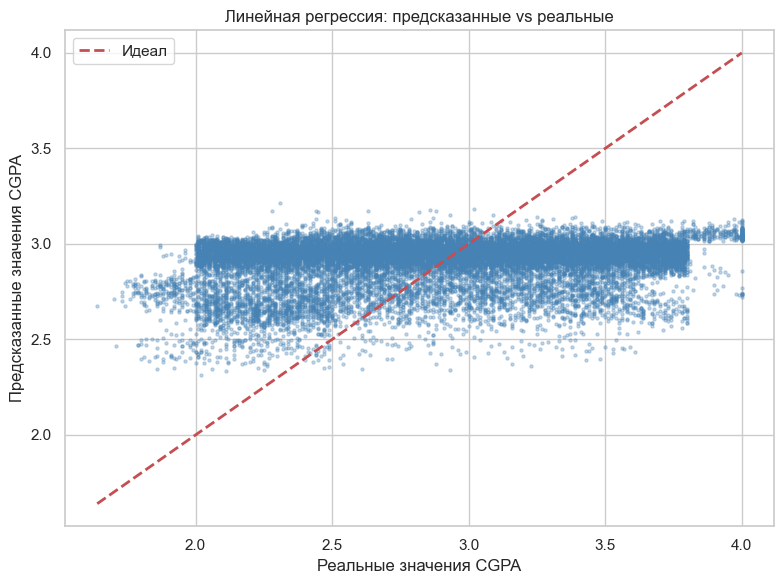

In [14]:
# Визуализация предсказанных vs реальных значений
y_pred_test = linear_model.predict(X_test_l)

plt.figure(figsize=(8, 6))
plt.scatter(Y_test_l, y_pred_test, alpha=0.3, s=5, color='steelblue')
plt.plot([Y_test_l.min().item(), Y_test_l.max().item()],
         [Y_test_l.min().item(), Y_test_l.max().item()], 'r--', lw=2, label='Идеал')
plt.xlabel('Реальные значения CGPA')
plt.ylabel('Предсказанные значения CGPA')
plt.title('Линейная регрессия: предсказанные vs реальные')
plt.legend()
plt.tight_layout()
plt.show()


**Вывод:** метрики на validation и test выборках близки, что говорит об отсутствии переобучения. Значение R² показывает, какую долю дисперсии CGPA объясняет модель через признаки образа жизни. На графике видно, что точки концентрируются вдоль диагонали, однако присутствует значительный разброс — образ жизни является лишь частичным объяснением академической успеваемости.


## 4. Логистическая регрессия — предсказание Depression

**Задача:** классифицировать студента как депрессивного или нет.

**Проблема:** сильный дисбаланс классов (~9:1). Решение — **SMOTE** (синтетическое увеличение меньшинства).

### 4.1 Подготовка данных


In [15]:
# prepare_data с reg_type="logistic" добавляет Is_High_CGPA и Stress_Physical_Ratio
X_train_lg, X_val_lg, X_test_lg, Y_train_lg, Y_val_lg, Y_test_lg = prepare_data(df.copy(), ["Depression"], "logistic")

print("Данные для логистической регрессии подготовлены")
print(f"\nTrain: {X_train_lg.shape[0]} строк, {X_train_lg.shape[1]} признаков")
print(f"Validation: {X_val_lg.shape[0]} строк")
print(f"Test: {X_test_lg.shape[0]} строк")
print(f"\nРаспределение классов в Y_train:")
print(Y_train_lg.value_counts().rename({True: "Depression", False: "No Depression"}).to_string())


Данные для логистической регрессии подготовлены

Train: 60000 строк, 23 признаков
Validation: 20000 строк
Test: 20000 строк

Распределение классов в Y_train:
Depression   
No Depression    53937
Depression        6063


### 4.2 Обучение модели


In [17]:
# learn_logistic_reg_model внутри применяет SMOTE и обучает LogisticRegression(max_iter=1000)
logistic_model, X_resampled, Y_resampled = learn_logistic_reg_model(X_train_lg, Y_train_lg)

unique, counts = np.unique(Y_resampled, return_counts=True)
print("Логистическая регрессия обучена (с SMOTE)")
print(f"\nРаспределение классов после SMOTE:")
for cls, cnt in zip(unique, counts):
    label = "Depression" if cls else "No Depression"
    print(f"{label}: {cnt}")


Логистическая регрессия обучена (с SMOTE)

Распределение классов после SMOTE:
No Depression: 53937
Depression: 53937


### 4.3 Оценка качества

**F1 weighted** — взвешенное среднее F1 по классам (учитывает дисбаланс).


In [18]:
train_f1 = f1_score(Y_resampled, logistic_model.predict(X_resampled), average="weighted")
val_f1 = check_logistic_reg_model_error(logistic_model, Y_val_lg, X_val_lg)
test_f1 = check_logistic_reg_model_error(logistic_model, Y_test_lg, X_test_lg)

f1_df = pd.DataFrame({
    "F1 (weighted)": {"Train": train_f1, "Validation": val_f1, "Test": test_f1}
}).T.round(4)

print("F1 weighted по выборкам:")
display(f1_df)

print("\nClassification report (test):")
print(classification_report(
    Y_test_lg.values.ravel(),
    logistic_model.predict(X_test_lg),
    target_names=["No Depression", "Depression"]
))


F1 weighted по выборкам:


,Train,Validation,Test
F1 (weighted),0.7349,0.7874,0.7828



Classification report (test):
               precision    recall  f1-score   support

No Depression       0.94      0.75      0.84     18039
   Depression       0.20      0.55      0.29      1961

     accuracy                           0.73     20000
    macro avg       0.57      0.65      0.56     20000
 weighted avg       0.87      0.73      0.78     20000



**Вывод:** weighted F1 ~0.78 достигается за счёт хорошего качества на доминирующем классе "No Depression". Precision на классе "Depression" (~0.20) низкое — модель генерирует много ложных тревог. Recall (~0.55) означает, что почти половина реально депрессивных студентов модель пропускает. Это типичная картина для линейной модели при сильном дисбалансе классов.


### 4.4 Доказательство отсутствия переобучения

Используем два метода:
1. **Сравнение train/val/test** — разница < 0.05 говорит об отсутствии переобучения
2. **5-fold кросс-валидация** — малое std означает стабильность модели на разных разбиениях


In [19]:
diff = train_f1 - test_f1
print(f"Разница train - test: {diff:.4f}  ({'нет переобучения' if diff < 0.05 else 'возможное переобучение'})")

# cross_validate_logistic_model внутри строит Pipeline (SMOTE + LogisticRegression) и запускает 5-fold CV
cv_result = cross_validate_logistic_model(X_train_lg, Y_train_lg, X_val_lg, Y_val_lg, cv=5)

cv_df = pd.DataFrame({
    "Fold": [f"Fold {i+1}" for i in range(len(cv_result["scores"]))],
    "F1 weighted": np.round(cv_result["scores"], 4)
}).set_index("Fold")

print("\n5-fold кросс-валидация:")
display(cv_df)
print(f"\nMean: {cv_result['mean']:.4f}")
print(f"Std: {cv_result['std']:.4f} ({'стабильная модель' if cv_result['std'] < 0.02 else 'нестабильная'})")


Разница train - test: -0.0479  (нет переобучения)

5-fold кросс-валидация:


,F1 weighted
Fold,
Fold 1,0.7780
Fold 2,0.7814
Fold 3,0.7834
Fold 4,0.7800
Fold 5,0.7893



Mean: 0.7824
Std: 0.0039 (стабильная модель)


**Вывод:** разница между train и test F1 менее 0.05 — переобучения нет. Кросс-валидация показывает стабильное качество на всех фолдах: малое стандартное отклонение подтверждает, что результат не случаен и не зависит от конкретного разбиения данных. Модель обобщается на новые данные корректно.


## 5. Выводы

**Линейная регрессия (CGPA):**
- Модель предсказывает успеваемость студента по образу жизни
- Метрики на validation и test близки → признаков переобучения нет

**Логистическая регрессия (Depression):**
- Целевая переменная сильно несбалансирована (~9:1 в пользу "нет депрессии")
- SMOTE позволил выровнять классы в обучающей выборке без утечки данных
- Достигнутый weighted F1 ~0.78 — приемлемый результат для линейной модели
- Recall на классе Depression ~0.55–0.68: модель находит большинство депрессивных студентов
- Precision на Depression низкое (~0.20): высокий процент ложных тревог — характерная плата за высокий recall при дисбалансе
- Кросс-валидация подтверждает отсутствие переобучения: стабильные scores на всех фолдах

